# Lecture 7 - Numerical Computing with NumPy

NumPy is the most commonly used Python library for numeric computing. While the math module from week 1 allows us to use Python as a scientific calculator, the numpy library will allow math capabilities far surpassing a graphics calculator. Official documentation can be found here: https://numpy.org/doc/stable/.

In [1]:
# importing numpy
import numpy as np

## Creating NumPy Arrays
NumPy gives us access to a new data type: the array. Arrays are similar to lists, but differ in important ways:
* Arrays can be multidimensional. A 1D array is similar to a list, but we can also create 2D, 3D, nD arrays.
* All elements of an array must have the same data type.
* Arrays include lots of mathematical functionality (eg. operators, functions, methods) which isn't the case for lists.

You can convert a list to an array with the <code>array</code> function in NumPy. There are also other functions available to quickly create common arrays such as <code>arange</code>, <code>linspace</code>, <code>ones</code> and <code>zeros</code>.

In [4]:
example_list = [5, 2, 7, 8]
example_list

[5, 2, 7, 8]

In [3]:
example_array = np.array(example_list)
example_array

array([5, 2, 7, 8])

In [5]:
example_matrix = np.array([[1, 2], [3, 4]])
example_matrix

array([[1, 2],
       [3, 4]])

In [6]:
# creating an evenly spaced array
numbers = np.linspace(1, 20, 5)
numbers

array([ 1.  ,  5.75, 10.5 , 15.25, 20.  ])

In [10]:
zero_matrix = np.zeros((4, 4))
zero_matrix

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

Once you have created an array, you can inspect its properties through its attributes. Attributes are values that are defined within a data type. You access them similarly to methods, except you do not call them (ie. no brackets). You can generally think of an attribute as a fact about the object whereas a method involves doing something to the object.

```python
value.attribute_name
```

Some useful attributes of arrays include <code>ndim</code>, <code>shape</code>, <code>size</code>, and <code>dtype</code>.

In [16]:
# examples
numbers.ndim

1

In [12]:
zero_matrix.ndim

2

In [13]:
zero_matrix.shape

(4, 4)

In [14]:
zero_matrix.dtype

dtype('float64')

## Element-wise Processes
NumPy supports elementwise operations, functions and indexing, avoiding the need for loops! An element-wise process is one that "does something" for each element. This allows you to more easily and efficiently perform calculations with collections of values than you could with Python's in-built data structures (lists, tuples, etc.).

In [17]:
# add 1 to each element of a list
new_list = []
for number in example_list:
    new_list.append(number + 1)
new_list

[6, 3, 8, 9]

In [22]:
# add 1 to each element of an array
new_array = example_array + 1
new_array

array([6, 3, 8, 9])

In [23]:
example_list + 1

TypeError: can only concatenate list (not "int") to list

In [25]:
example_array + new_array

array([11,  5, 15, 17])

In [26]:
example_array * 10

array([50, 20, 70, 80])

In [27]:
# math functions are elementwise in numpy also
np.sin(example_array)

array([-0.95892427,  0.90929743,  0.6569866 ,  0.98935825])

In [28]:
# math module can only handle one number at a time
import math
math.sin(example_array)

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [29]:
# relational operators are also elementwise in numpy
example_array < 5

array([False,  True, False, False])

In [30]:
example_list < 5

TypeError: '<' not supported between instances of 'list' and 'int'

## Indexing and Slicing
NumPy arrays can be indexed and sliced like lists. 

In addition to slicing, it will allow for a sequence of indexes to be provided to select a subset of an array, meaning you can select any subset and not just adjacent elements.

Further functionality is also available for higher dimensional arrays, since arrays understand the concept of dimensionality. For example, in a matrix you could index with:
```{python}
matrix_name[row_index, col_index]
```

In [31]:
# examples
numbers[0] # select first element

np.float64(1.0)

In [32]:
numbers[-1] # select last element

np.float64(20.0)

In [33]:
numbers[2:5] # select elements 3 to 5

array([10.5 , 15.25, 20.  ])

In [34]:
example_matrix[0, 1] # select first row, 2nd column

np.int64(2)

In [35]:
numbers[[0, 2, 3]] # custom selection of indexes

array([ 1.  , 10.5 , 15.25])

In [37]:
example_matrix[0, :] # select entire first row

array([1, 2])

In [38]:
example_matrix[:, 1] # select second column

array([2, 4])

## Plotting with Matplotlib
Matplotlib is the most common library used to visualise numeric data in Python, and is commonly used in tandem with NumPy. Documentation can be found here: https://matplotlib.org/stable/index.html.

In [39]:
# matplotlib import
import matplotlib.pyplot as plt

Text(0, 0.5, 'y = sin(x)')

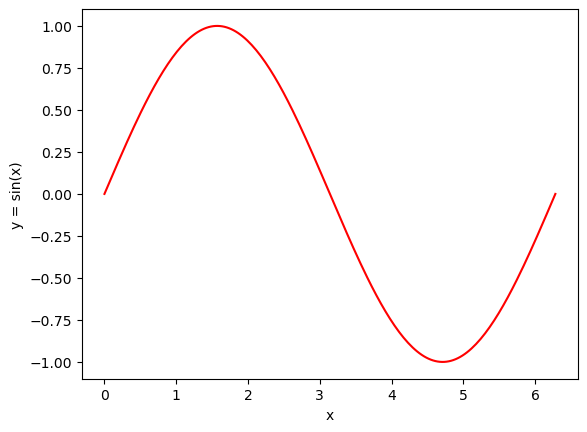

In [49]:
# example - provided in MatPlotLib documentation

# creating arrays
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots() # create blank figure and axes
ax.plot(x, y, color='red') # plot onto axes
ax.set_xlabel('x')
ax.set_ylabel('y = sin(x)')

## Mathematics with NumPy
NumPy has functionality to support more advanced mathematics beyond the math module. This includes statistics, linear algebra and numerical methods.

### Example: Numerical methods
An underdamped motor lifting a mass produces a velocity profile given by the equation $v(t) = 1-e^{-t}\cos(10t)$ for $0 < t < 10$. 
1. Visualise the velocity with a plot.
2. Numerically compute the acceleration, noting $a = \cfrac{dv}{dt}$.
3. Numerically compute the position, noting $s = \int v \ dt$.
4. Visualise the position, velocity and acceleration behaviour in a single plot.

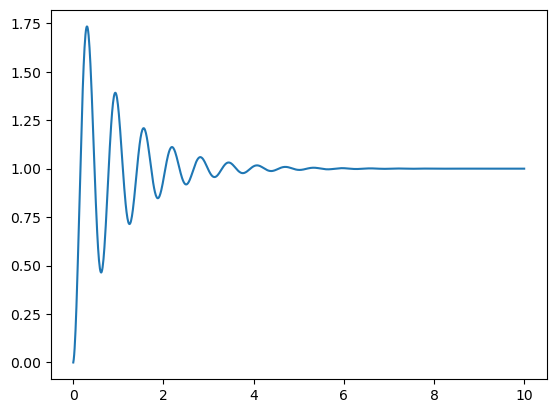

In [51]:
# step 1
t = np.linspace(0, 10, 1000)
vel = 1 - np.exp(-t) * np.cos(10*t)
fig, ax = plt.subplots() # create blank figure and axes
ax.plot(t, vel) # plot onto axes


In [53]:
# step 2 - diffentiating
acc = np.diff(vel) / np.diff(t)

In [55]:
# step 3 - integrating
dt = t[1] - t[0]
delta_x = vel * dt
pos = np.cumsum(delta_x)

Text(0.5, 0, 'time')

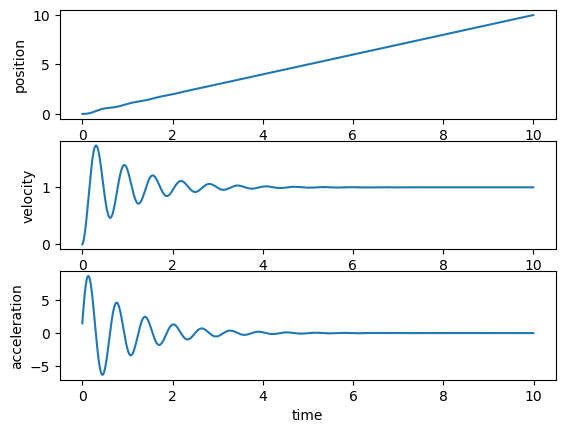

In [63]:
# step 4 - plotting everything
fig, ax = plt.subplots(3, 1) # create blank figure and axes
ax[0].plot(t, pos)
ax[0].set_ylabel('position')
ax[1].plot(t, vel) # plot onto axes
ax[1].set_ylabel('velocity')
ax[2].plot(t[:-1], acc)
ax[2].set_ylabel('acceleration')
ax[2].set_xlabel('time')